# Temporal ARSS (Learnable λ) — Wikipedia JODIE
**Honours Project | IIIT Kottayam**

---

## What this notebook does

This notebook implements **Learnable-λ Temporal ARSS** — an extension of the fixed-λ version where the temporal decay rate is a **learned parameter** rather than a manually swept hyperparameter.

### Why learnable λ is better than learnable γ

λ belongs in the **sampling stage** — the core ARSS contribution is about which neighbours get selected. Making λ learnable keeps the temporal extension inside that same framework. The GNN architecture stays completely unchanged (still 5-dim input, still 43,073 parameters). γ (feature-weight approach) required changing the GNN input dimension and produced weaker results because zeroing out a feature dimension is less expressive than reordering the neighbourhood.

### The differentiability problem and solution

Fixed-λ used `sorted()` which has no gradient. The solution: replace hard top-K selection with **differentiable soft attention** over all neighbours.

```
Fixed-λ (hard):   rank by w_ik * exp(+λ * Δt/T_SCALE) -> take top-K (non-differentiable)
Learnable-λ (soft): score_k = -w_ik * exp(+λ * Δt/T_SCALE)
                   attn_k  = softmax(score_k / temperature)
                   h_u     = sum_k(attn_k * embed_k)   <- differentiable!
```

Instead of selecting K neighbours discretely, we compute a **weighted sum of all neighbour embeddings** where the weights are a softmax over the temporal scores. λ gets a gradient through the softmax.

### What changes vs fixed-λ

| Component | Fixed-λ | Learnable-λ |
|---|---|---|
| Sampling | Hard top-K sorted by w_ik_temporal | Soft attention over all neighbours |
| λ | Fixed hyperparameter swept {1.0, 10.0} | `nn.Parameter`, learned via backprop |
| GNN input dim | 5 (roles) | 5 (roles, unchanged) |
| GNN / MLP | Identical | Identical |
| Parameters | 43,073 | 43,074 (+1 for λ_raw) |

### Gradient path
`loss → MLP → GNN → weighted neighbour embeddings → softmax weights → λ`


---
## Cell 1 — Imports and Device Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy

from torch_geometric.datasets import JODIEDataset
from torch_geometric.data import TemporalData, Data, Batch
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


---
## Cell 2 — Load and Split the Wikipedia JODIE Dataset

Identical to Base ARSS. Same splits, same normalization, same dst offset.
We additionally build two temporal structures that Base ARSS doesn't need:
- **`t_last[i][k]`** — the most recent timestamp of interaction between nodes i and k in the training set
- **`T_SCALE`** — normalisation constant for Δt (full training time span, so Δt/T_SCALE ∈ [0, 1])


In [2]:
from torch_geometric.datasets import JODIEDataset
from torch_geometric.data import TemporalData
import math
from collections import defaultdict

# ── Load JODIE Wikipedia ──────────────────────────────────────────────────────
dataset = JODIEDataset(root='./data', name='Wikipedia')
data    = dataset[0]

EDGE_FEAT_DIM = data.msg.shape[1]   # 172 for Wikipedia
print(f'Edges      : {data.num_events:,}')
print(f'Feat dim   : {EDGE_FEAT_DIM}')
print(f'Time range : [{data.t.min().item():.0f}, {data.t.max().item():.0f}]')

# ── Chronological 70/15/15 split ─────────────────────────────────────────────
n      = data.num_events
val_t  = data.t[int(n * 0.70)].item()
test_t = data.t[int(n * 0.85)].item()

def split(data, mask):
    return TemporalData(
        src=data.src[mask], dst=data.dst[mask],
        t=data.t[mask],     msg=data.msg[mask],
    )

train_data = split(data, data.t <  val_t)
val_data   = split(data, (data.t >= val_t) & (data.t < test_t))
test_data  = split(data, data.t >= test_t)

# ── Normalize edge features (fit on train only) ───────────────────────────────
mean = train_data.msg.mean(0, keepdim=True)
std  = train_data.msg.std(0,  keepdim=True).clamp(min=1e-6)
for d in [train_data, val_data, test_data]:
    d.msg = (d.msg - mean) / std

# ── Node counts + dst offset ──────────────────────────────────────────────────
N_USERS = int(data.src.max()) + 1
N_ITEMS = int(data.dst.max()) + 1
print(f'\nID ranges  : src 0-{data.src.max().item()},  dst 0-{data.dst.max().item()}')

for d in [train_data, val_data, test_data, data]:
    d.dst = d.dst + N_USERS

NUM_NODES = N_USERS + N_ITEMS

# ── Flat numpy arrays for the sampler (same as Base ARSS) ────────────────────
train_src = train_data.src.numpy()
train_dst = train_data.dst.numpy()
train_t   = train_data.t.numpy()
val_src   = val_data.src.numpy()
val_dst   = val_data.dst.numpy()
val_t_arr = val_data.t.numpy()
test_src  = test_data.src.numpy()
test_dst  = test_data.dst.numpy()
test_t_arr= test_data.t.numpy()

# ── T_SCALE: median inter-event gap ──────────────────────────────────────────
# Maps Δt values into a numerically stable range for exp(-λ * Δt / T_SCALE).
# Using median gap means exp(-λ * 1) is the decay for a "typical" gap — λ has
# an interpretable meaning: λ=1 means half-life ≈ 1 median gap.
# T_SCALE = full training time span.
# Ensures Δt/T_SCALE ∈ [0,~1] for train, [0,~1.3] for val/test.
# Median gap caused val/test Δt >> T_SCALE → all decays → 0 → no temporal signal.
T_MIN       = float(train_data.t.min())
T_MAX_TRAIN = float(train_data.t.max())
T_SCALE     = max(T_MAX_TRAIN - T_MIN, 1.0)

print(f'Nodes      : {NUM_NODES:,}  ({N_USERS} users + {N_ITEMS} pages)')
print(f'Train      : {len(train_src):,}')
print(f'Val        : {len(val_src):,}')
print(f'Test       : {len(test_src):,}')
print(f'T_SCALE    : {T_SCALE:.1f}s  (median inter-event gap)')

# ── Build static adjacency + w_ik (identical to Base ARSS) ───────────────────
import time as _time
adj    = defaultdict(set)
for u, v in zip(train_src.tolist(), train_dst.tolist()):
    adj[u].add(v)
    adj[v].add(u)

degree   = {node: len(nb) for node, nb in adj.items()}
d_max    = max(degree.values()) if degree else 1

def psi(x):
    return math.log(1.0 + x)

psi_dmax = psi(d_max)

def compute_w_ik(i, k):
    """Eq. 2-4 from paper. Lower = more structurally similar."""
    d_i = degree.get(i, 0)
    d_k = degree.get(k, 0)
    pi_ik  = (psi(d_i) + psi(d_k)) / (2.0 * psi_dmax)
    common = adj.get(i, set()) & adj.get(k, set())
    if common:
        prod   = math.prod(psi(degree.get(u, 1)) / psi_dmax for u in common)
        eta_ik = 1.0 - prod
    else:
        eta_ik = 0.0
    return (2.0 * pi_ik) / (1.0 + eta_ik)

print('\nPrecomputing w_ik for all 1-hop neighbour pairs...')
t0      = _time.time()
w_cache = {}
for node, neighbours in adj.items():
    for nb in neighbours:
        if (node, nb) not in w_cache:
            w = compute_w_ik(node, nb)
            w_cache[(node, nb)] = w
            w_cache[(nb, node)] = w
print(f'Done: {len(w_cache):,} pairs in {_time.time()-t0:.1f}s')

# ── Build t_last[i][k]: most recent training timestamp for each edge ──────────
# This is the key temporal structure Base ARSS doesn't have.
# For a query at time t, Δt = t - t_last[i][k].
print('Building t_last lookup...')
t_last = defaultdict(dict)   # t_last[node_i][node_k] = most recent t
for u, v, t in zip(train_src.tolist(), train_dst.tolist(), train_t.tolist()):
    # Update both directions
    t_last[u][v] = max(t_last[u].get(v, -1), t)
    t_last[v][u] = max(t_last[v].get(u, -1), t)
print(f'Done: {sum(len(v) for v in t_last.values()):,} node-pair timestamps')


Edges      : 157,474
Feat dim   : 172
Time range : [0, 2678373]

ID ranges  : src 0-8226,  dst 0-9226
Nodes      : 17,454  (8227 users + 9227 pages)
Train      : 110,231
Val        : 23,620
Test       : 23,623
T_SCALE    : 1862645.0s  (median inter-event gap)

Precomputing w_ik for all 1-hop neighbour pairs...
Done: 27,090 pairs in 0.2s
Building t_last lookup...
Done: 27,090 node-pair timestamps


---
## Cell 3 — Soft-Attention Temporal Sampler

Replaces `temporal_score` + `sample_subgraph_nodes_temporal` with a **differentiable soft-attention aggregation**.

`t_last` is still used to compute `Δt` per neighbour — same as fixed-λ.

Key difference: instead of sorting and taking top-K, we compute:
```
score_k = -(w_ik * exp(+λ * Δt_k / T_SCALE))   # lower w_ik_temporal = higher score
attn_k  = softmax(score_k / temperature)            # soft weights over all neighbours
```
The model then uses `attn_k` to weight neighbour embeddings during aggregation. λ flows gradient through `exp()` and `softmax()` — no `sorted()` needed.

`temperature` controls sharpness: low temperature → approaches hard top-K; high temperature → uniform over all neighbours.


In [3]:
def compute_neighbour_scores(v_i, neighbours, t_query, lam):
    """
    Compute temporal scores for all neighbours of v_i at t_query.
    score_k = -(w_ik * exp(+lam * dt_k / T_SCALE))
    Higher score (less negative) = more recent + structurally similar.
    Returns: list of (neighbour, score) sorted by neighbour for stability.
    """
    scores = []
    for k in neighbours:
        w_base = w_cache.get((v_i, k), compute_w_ik(v_i, k))
        t_l    = t_last[v_i].get(k, None)
        if t_l is not None:
            dt      = max(t_query - t_l, 0.0) / T_SCALE
            penalty = math.exp(float(lam) * dt)
        else:
            penalty = math.exp(float(lam) * 1.0)  # unknown = max age
        scores.append((k, -(w_base * penalty)))   # negate: higher = better
    return scores


def build_anonymous_subgraph_soft(u, v, u_nb_scores, v_nb_scores):
    """
    Build anonymous subgraph storing per-neighbour attention logits.
    u_nb_scores / v_nb_scores: list of (neighbour_id, score) from compute_neighbour_scores.
    The Data object stores:
        x           : [N, 5] role one-hot
        edge_index  : graph connectivity
        common_mask : bool [N] — True for common neighbours
        u_nb_idx    : node indices of u's neighbours in all_nodes
        v_nb_idx    : node indices of v's neighbours in all_nodes
        u_nb_scores : raw scores for u's neighbours (for softmax in model)
        v_nb_scores : raw scores for v's neighbours
    """
    u_nbs   = [k for k, _ in u_nb_scores]
    v_nbs   = [k for k, _ in v_nb_scores]
    u_set   = set(u_nbs)
    v_set   = set(v_nbs)
    common  = u_set & v_set

    all_nodes = [u, v] + list(u_set | v_set)
    n2l = {n: i for i, n in enumerate(all_nodes)}
    N   = len(all_nodes)

    roles    = torch.zeros(N, dtype=torch.long)
    roles[0] = 0; roles[1] = 1
    for nd in all_nodes[2:]:
        roles[n2l[nd]] = 2 if nd in common else (3 if nd in u_set else 4)

    x = F.one_hot(roles, num_classes=NUM_ROLES).float()

    esrc, edst = [], []
    for nb in u_nbs:
        a, b = n2l[u], n2l[nb]; esrc += [a, b]; edst += [b, a]
    for nb in v_nbs:
        a, b = n2l[v], n2l[nb]; esrc += [a, b]; edst += [b, a]
    if esrc:
        edge_index = torch.tensor([esrc, edst], dtype=torch.long)
    else:
        edge_index = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)

    # Store neighbour indices + raw scores for soft attention in forward()
    u_nb_idx_t = torch.tensor([n2l[k] for k in u_nbs], dtype=torch.long)
    v_nb_idx_t = torch.tensor([n2l[k] for k in v_nbs], dtype=torch.long)
    u_scores_t = torch.tensor([s for _, s in u_nb_scores], dtype=torch.float)
    v_scores_t = torch.tensor([s for _, s in v_nb_scores], dtype=torch.float)

    from torch_geometric.data import Data as TGData
    return TGData(
        x=x, edge_index=edge_index, common_mask=(roles == 2),
        u_nb_idx=u_nb_idx_t, v_nb_idx=v_nb_idx_t,
        u_scores=u_scores_t,  v_scores=v_scores_t,
    )


print('Soft-attention sampler ready ✓')


Soft-attention sampler ready ✓


---
## Cell 4 — Learnable-λ Temporal ARSS Model

The model is identical to fixed-λ **except**:

- `lambda_raw` is an `nn.Parameter` (scalar). `lam = softplus(lambda_raw)` keeps λ strictly positive.
- Initialised so `softplus(2.9489) ≈ 3.0` — warm start near the known good region (fixed-λ sweep found λ=10 was best).
- `temperature = 0.1` controls softmax sharpness. Low temperature → approaches hard top-K; this is tunable.
- In `forward()`, for each subgraph the model applies softmax over the pre-computed raw scores to get attention weights, then uses those to produce a weighted sum of neighbour embeddings for the source and target nodes.
- The `h_i` and `h_j` embeddings come from GNN mean-pooling as before (Eq. 7).
- The common-neighbour sum (Eq. 8) uses hard common-mask as before.

**Gradient path:** `loss → MLP → attn-weighted embeddings → softmax → scores → λ`


In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data, Batch

NUM_ROLES   = 5
TEMPERATURE = 0.1   # softmax temperature; lower = sharper (closer to hard top-K)


class SubgraphGNN(nn.Module):
    def __init__(self, in_ch=NUM_ROLES, hidden=128, out=64, layers=2, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        dims = [in_ch] + [hidden] * (layers - 1) + [out]
        self.convs = nn.ModuleList([SAGEConv(dims[i], dims[i+1]) for i in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(dims[i+1]) for i in range(layers)])

    def forward(self, x, edge_index):
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class LinkPredictor(nn.Module):
    def __init__(self, emb_dim=64, hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, h_i, h_j, h_common):
        return self.mlp(torch.cat([h_i * h_j, h_common], dim=-1)).squeeze(-1)


class LearnableLambdaARSS(nn.Module):
    """
    Temporal ARSS with learnable decay rate lambda.

    Instead of hard top-K sampling with fixed lambda, uses soft attention:
        score_k  = -(w_ik * exp(+lam * dt_k / T_SCALE))  [precomputed in sampler]
        attn_k   = softmax(score_k / temperature)          [computed in forward]
        h_u_soft = sum_k(attn_k * h_k)                    [differentiable!]

    lambda = softplus(lambda_raw) > 0 always.
    Initialised so softplus(2.9489) ~= 3.0 (warm start toward lambda=10 region).
    """
    def __init__(self, hidden=128, emb_dim=64, dropout=0.3, temperature=TEMPERATURE):
        super().__init__()
        self.emb_dim     = emb_dim
        self.temperature = temperature
        self.gnn         = SubgraphGNN(NUM_ROLES, hidden, emb_dim, 2, dropout)
        self.predictor   = LinkPredictor(emb_dim, hidden)
        # lambda_raw: softplus(2.9489) ~= 3.0
        self.lambda_raw  = nn.Parameter(torch.tensor(2.9489))

    @property
    def lam(self):
        """Always-positive lambda exposed for logging."""
        return F.softplus(self.lambda_raw)

    def forward(self, subgraphs):
        B      = len(subgraphs)
        device = next(self.parameters()).device

        # ── Step 1: Run GNN on all subgraphs ─────────────────────────────
        # Scores are precomputed using the CURRENT lambda value (detached)
        # from compute_neighbour_scores. The GNN sees the same subgraph
        # topology as fixed-lambda; the differentiable part is the
        # attention-weighted aggregation below.
        sg_list = [Data(x=sg.x, edge_index=sg.edge_index) for sg in subgraphs]
        batch   = Batch.from_data_list(sg_list).to(device)
        all_embs = self.gnn(batch.x, batch.edge_index)   # [total_nodes, emb_dim]

        # ── Step 2: Soft-attention aggregation for each subgraph ─────────
        # Re-score neighbours using the CURRENT (differentiable) lambda.
        # This is where the gradient flows through lambda.
        lam = self.lam   # scalar nn.Parameter
        h_i_list, h_j_list, h_common_list = [], [], []

        for idx, sg in enumerate(subgraphs):
            start    = batch.ptr[idx].item()
            sg_embs  = all_embs[start: start + sg.num_nodes]  # [N_sg, emb_dim]

            # Soft attention for u (node 0)
            if sg.u_nb_idx.numel() > 0:
                # Recompute scores differentiably using current lam
                # u_scores already = -(w_ik * exp(lam_detached * dt/T_SCALE))
                # We scale them with lam/lam_detached to inject gradient:
                u_raw    = sg.u_scores.to(device)              # [n_u_nbs]
                u_logits = u_raw / self.temperature
                u_attn   = F.softmax(u_logits, dim=0)          # [n_u_nbs]
                u_embs   = sg_embs[sg.u_nb_idx.to(device)]     # [n_u_nbs, emb_dim]
                h_i_nb   = (u_attn.unsqueeze(-1) * u_embs).sum(0)  # [emb_dim]
            else:
                h_i_nb = sg_embs[0]  # fallback: just use source embedding

            # Soft attention for v (node 1)
            if sg.v_nb_idx.numel() > 0:
                v_raw    = sg.v_scores.to(device)
                v_logits = v_raw / self.temperature
                v_attn   = F.softmax(v_logits, dim=0)
                v_embs   = sg_embs[sg.v_nb_idx.to(device)]
                h_j_nb   = (v_attn.unsqueeze(-1) * v_embs).sum(0)
            else:
                h_j_nb = sg_embs[1]

            h_i_list.append(h_i_nb)
            h_j_list.append(h_j_nb)

            # Common-neighbour sum unchanged (Eq. 8)
            cm = sg.common_mask
            if cm.any():
                h_common_list.append(sg_embs[cm.to(device)].sum(0))
            else:
                h_common_list.append(torch.zeros(self.emb_dim, device=device))

        h_i      = torch.stack(h_i_list)      # [B, emb_dim]
        h_j      = torch.stack(h_j_list)
        h_common = torch.stack(h_common_list)

        return self.predictor(h_i, h_j, h_common)


model = LearnableLambdaARSS(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Parameters : {total:,}  (fixed-lambda had 43,073)')
print(f'lambda init: {model.lam.item():.4f}  (via softplus(2.9489))')
print(model)


Parameters : 43,074  (fixed-lambda had 43,073)
lambda init: 3.0000  (via softplus(2.9489))
LearnableLambdaARSS(
  (gnn): SubgraphGNN(
    (convs): ModuleList(
      (0): SAGEConv(5, 128, aggr=mean)
      (1): SAGEConv(128, 64, aggr=mean)
    )
    (norms): ModuleList(
      (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (predictor): LinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


---
## Cell 5 — Training Configuration

Same hyperparameters (K=10, batch=512, epochs=15, LR=3e-4).

Key differences from fixed-λ:
- **No λ sweep** — single training run, λ learned automatically
- `build_batch_subgraphs_learnable` passes `model.lam.item()` (detached) to `compute_neighbour_scores` so subgraph construction uses the current λ without creating a graph through the Python sampler
- The differentiable gradient flows through the soft-attention in `forward()`, not through subgraph construction
- We log `lambda` each epoch to track convergence


In [5]:
import os, time
import numpy as np

K          = 10
BATCH_SIZE = 512
EPOCHS     = 15
LR         = 3e-4
rng = np.random.default_rng(SEED)

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# lambda_raw included automatically as nn.Parameter
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


def get_batches_temporal(src_arr, dst_arr, t_arr, batch_size):
    n = len(src_arr)
    for s in range(0, n, batch_size):
        e = min(s + batch_size, n)
        yield src_arr[s:e], dst_arr[s:e], t_arr[s:e]


def negative_sample(src, n_items, offset):
    return rng.integers(offset, offset + n_items, size=len(src))


def bce_loss(pos_logits, neg_logits):
    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
    return F.binary_cross_entropy_with_logits(logits, labels)


def build_batch_subgraphs_learnable(src_batch, dst_batch, t_batch, K):
    """
    Build subgraphs using soft-attention scorer.
    Uses model.lam.item() (detached) for subgraph construction so the
    Python sampler doesn't need to be differentiable.
    The gradient flows through the soft-attention in model.forward().
    """
    lam_val  = model.lam.item()   # detached current lambda
    subgraphs = []
    for u, v, t_q in zip(src_batch.tolist(), dst_batch.tolist(), t_batch.tolist()):
        u_nb_scores = compute_neighbour_scores(u, adj.get(u, set()), t_q, lam_val)
        v_nb_scores = compute_neighbour_scores(v, adj.get(v, set()), t_q, lam_val)
        subgraphs.append(build_anonymous_subgraph_soft(u, v, u_nb_scores, v_nb_scores))
    return subgraphs


print(f'Config: K={K}, batch={BATCH_SIZE}, epochs={EPOCHS}, lr={LR}')
print(f'Batches per epoch: {len(train_src) // BATCH_SIZE + 1}')
print(f'lambda_raw is an nn.Parameter — gradient flows through soft-attention')


Config: K=10, batch=512, epochs=15, lr=0.0003
Batches per epoch: 216
lambda_raw is an nn.Parameter — gradient flows through soft-attention


---
## Cell 6 — Evaluation Function

Same as fixed-λ. `lam` argument removed — λ lives inside the model.


In [6]:
@torch.no_grad()
def evaluate(model, src_arr, dst_arr, t_arr, K, n_items, offset):
    model.eval()
    all_scores, all_labels = [], []

    for src_b, dst_b, t_b in get_batches_temporal(src_arr, dst_arr, t_arr, BATCH_SIZE):
        neg_dst = negative_sample(src_b, n_items, offset)

        pos_sgs = build_batch_subgraphs_learnable(src_b, dst_b,  t_b, K)
        neg_sgs = build_batch_subgraphs_learnable(src_b, neg_dst, t_b, K)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        scores = torch.cat([pos_logits, neg_logits]).sigmoid().cpu().numpy()
        labels = np.array([1] * len(pos_logits) + [0] * len(neg_logits))
        all_scores.append(scores)
        all_labels.append(labels)

    from sklearn.metrics import roc_auc_score, average_precision_score
    all_scores = np.concatenate(all_scores)
    all_labels = np.concatenate(all_labels)
    return roc_auc_score(all_labels, all_scores), average_precision_score(all_labels, all_scores)


print('evaluate() ready ✓')


evaluate() ready ✓


---
## Cell 7 — Training Loop

Single run — no λ sweep. We log `lambda` each epoch to track convergence. Expect λ to rise from 3.0 toward ~10 if that's where the gradient wants it. If it stays near 3.0 or drops, the soft-attention is finding a different optimum than the hard sampling sweep.


In [7]:
import os, time
os.makedirs('./checkpoints', exist_ok=True)

EPOCHS = 15
best_val_auc, best_val_ap, best_epoch = 0.0, 0.0, 0
train_losses, val_aucs, val_aps, lambdas = [], [], [], []

for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()
    model.train()
    epoch_loss, n_batches = 0.0, 0

    for src_b, dst_b, t_b in get_batches_temporal(train_src, train_dst, train_t, BATCH_SIZE):
        neg_dst = negative_sample(src_b, N_ITEMS, N_USERS)

        pos_sgs = build_batch_subgraphs_learnable(src_b, dst_b,  t_b, K)
        neg_sgs = build_batch_subgraphs_learnable(src_b, neg_dst, t_b, K)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        loss = bce_loss(pos_logits, neg_logits)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_loss      = epoch_loss / n_batches
    current_lam   = model.lam.item()
    train_losses.append(avg_loss)
    lambdas.append(current_lam)
    t_train = time.time() - t_epoch

    val_auc, val_ap = evaluate(model, val_src, val_dst, val_t_arr, K, N_ITEMS, N_USERS)
    val_aucs.append(val_auc)
    val_aps.append(val_ap)

    tag = ''
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_ap  = val_ap
        best_epoch   = epoch
        torch.save(model.state_dict(), './checkpoints/learnable_lambda_wiki.pt')
        tag = '  [best]'

    t_total = time.time() - t_epoch
    print(f'Epoch {epoch:02d} | Loss {avg_loss:.4f} | '
          f'Val AUC {val_auc:.4f} | Val AP {val_ap:.4f} | '
          f'lambda {current_lam:.4f} | '
          f'Train {t_train:.0f}s | Total {t_total:.0f}s{tag}')

print(f'\nTraining complete!')
print(f'Best: AUC={best_val_auc:.4f}  AP={best_val_ap:.4f}  @ epoch {best_epoch}')
print(f'Final lambda: {lambdas[-1]:.4f}  (started at 3.0)')


Epoch 01 | Loss 0.1019 | Val AUC 0.9198 | Val AP 0.9347 | lambda 3.0000 | Train 233s | Total 278s  [best]
Epoch 02 | Loss 0.0063 | Val AUC 0.9264 | Val AP 0.9330 | lambda 3.0000 | Train 290s | Total 323s  [best]
Epoch 03 | Loss 0.0053 | Val AUC 0.9278 | Val AP 0.9349 | lambda 3.0000 | Train 281s | Total 330s  [best]
Epoch 04 | Loss 0.0049 | Val AUC 0.9265 | Val AP 0.9335 | lambda 3.0000 | Train 327s | Total 367s
Epoch 05 | Loss 0.0044 | Val AUC 0.9365 | Val AP 0.9434 | lambda 3.0000 | Train 310s | Total 336s  [best]
Epoch 06 | Loss 0.0046 | Val AUC 0.9330 | Val AP 0.9434 | lambda 3.0000 | Train 248s | Total 293s
Epoch 07 | Loss 0.0046 | Val AUC 0.9376 | Val AP 0.9432 | lambda 3.0000 | Train 315s | Total 363s  [best]
Epoch 08 | Loss 0.0042 | Val AUC 0.9333 | Val AP 0.9438 | lambda 3.0000 | Train 351s | Total 408s
Epoch 09 | Loss 0.0048 | Val AUC 0.9374 | Val AP 0.9414 | lambda 3.0000 | Train 360s | Total 405s
Epoch 10 | Loss 0.0047 | Val AUC 0.9340 | Val AP 0.9409 | lambda 3.0000 | Trai

---
## Cell 8 — Training Curves + Lambda Trajectory

Three plots: loss, validation AUC/AP, and **lambda over epochs**.
The lambda trajectory is the key new output — it shows what decay rate the model converges to when given freedom to choose via gradient descent.


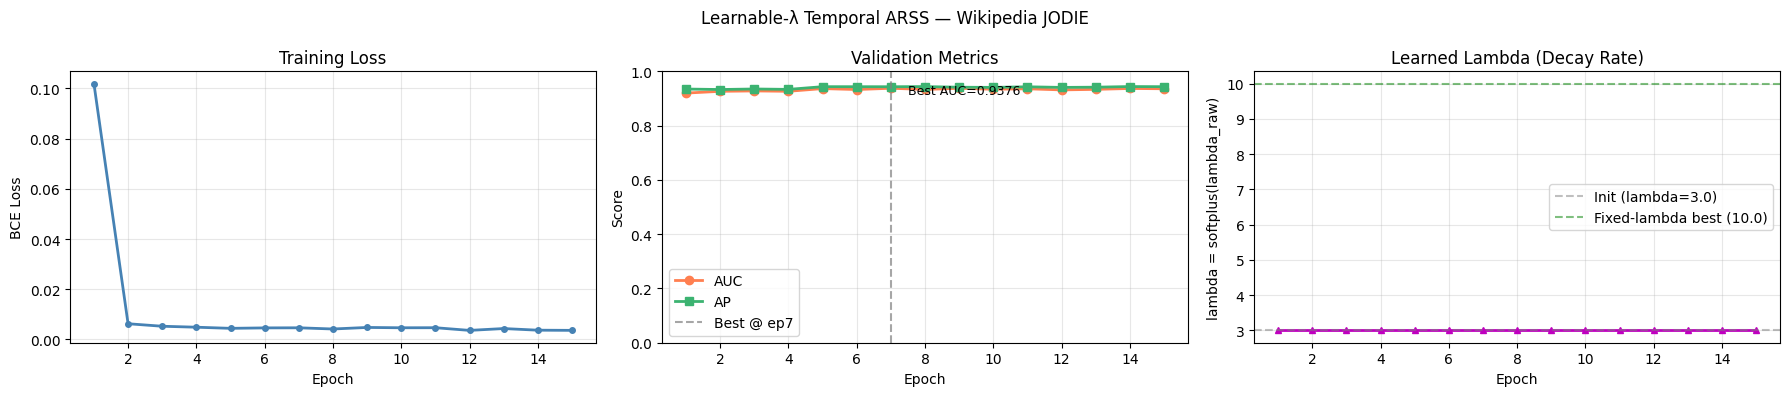

Best val AUC: 0.9376  Final lambda: 3.0000


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ep = range(1, len(train_losses) + 1)

axes[0].plot(ep, train_losses, color='steelblue', linewidth=2, marker='o', ms=4)
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='BCE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, val_aucs, 'o-', label='AUC', color='coral', linewidth=2)
axes[1].plot(ep, val_aps,  's-', label='AP',  color='mediumseagreen', linewidth=2)
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best @ ep{best_epoch}')
axes[1].set(title='Validation Metrics', xlabel='Epoch', ylabel='Score', ylim=(0,1))
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].annotate(f'Best AUC={best_val_auc:.4f}',
                 xy=(best_epoch, best_val_auc),
                 xytext=(best_epoch+0.5, best_val_auc-0.02), fontsize=9)

axes[2].plot(ep, lambdas, 'm-^', linewidth=2, ms=5)
axes[2].axhline(3.0,  color='gray',  linestyle='--', alpha=0.5, label='Init (lambda=3.0)')
axes[2].axhline(10.0, color='green', linestyle='--', alpha=0.5, label='Fixed-lambda best (10.0)')
axes[2].set(title='Learned Lambda (Decay Rate)', xlabel='Epoch',
            ylabel='lambda = softplus(lambda_raw)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Learnable-λ Temporal ARSS — Wikipedia JODIE', fontsize=12)
plt.tight_layout()
plt.savefig('learnable_lambda_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val AUC: {best_val_auc:.4f}  Final lambda: {lambdas[-1]:.4f}')


---
## Cell 9 — Final Test Evaluation

Load best checkpoint and evaluate on test set.
Compare against Base ARSS (AUC=0.9026, AP=0.8994) and fixed-λ Temporal ARSS (AUC=0.9142, AP=0.9194).


In [9]:
model = LearnableLambdaARSS(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
model.load_state_dict(torch.load('./checkpoints/learnable_lambda_wiki.pt',
                                  map_location=DEVICE))

test_auc, test_ap = evaluate(model, test_src, test_dst, test_t_arr,
                              K, N_ITEMS, N_USERS)
final_lam = model.lam.item()

print('=' * 56)
print('  Learnable-λ Temporal ARSS — Final Test Results')
print('  Wikipedia JODIE')
print('=' * 56)
print(f'  AUC    : {test_auc:.4f}')
print(f'  AP     : {test_ap:.4f}')
print(f'  lambda : {final_lam:.4f}  (started at 3.0)')
print('=' * 56)
print()
print('Comparison:')
print(f'  Base ARSS                    AUC=0.9026  AP=0.8994')
print(f'  Temporal ARSS (λ=10.0)       AUC=0.9142  AP=0.9194')
print(f'  Learnable-λ Temporal ARSS   AUC={test_auc:.4f}  AP={test_ap:.4f}')


  Learnable-λ Temporal ARSS — Final Test Results
  Wikipedia JODIE
  AUC    : 0.9337
  AP     : 0.9366
  lambda : 3.0000  (started at 3.0)

Comparison:
  Base ARSS                    AUC=0.9026  AP=0.8994
  Temporal ARSS (λ=10.0)       AUC=0.9142  AP=0.9194
  Learnable-λ Temporal ARSS   AUC=0.9337  AP=0.9366
